In [1]:
!pip install fredapi

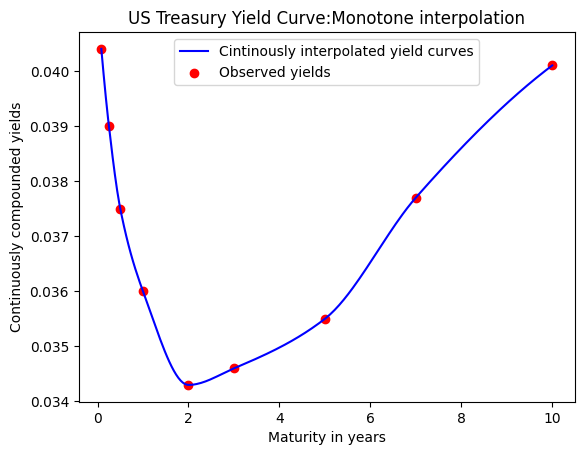

In [2]:
# Importing main required libraries
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy.interpolate import PchipInterpolator

# Then calling Fred with Fred API
fred=Fred(api_key= "317771cf4caa5305d10e5ce9639b61b0")

# Creating a dictionary of various bond maturities
maturities= {
    "1m":"DGS1MO",
    "3m":"DGS3MO",
    "6m":"DGS6MO",
    "1y":"DGS1",
    "2y":"DGS2",
    "3y":"DGS3",
    "5y":"DGS5",
    "7y":"DGS7",
    "10y":"DGS10"
}

# We have defined here tenors in a list same as in maturity dictionary
tenors=np.array([1/12,3/12,6/12,1,2,3,5,7,10])

# Now we have defined a for loop to get time series of yield curves and then using very current yields from that time series.
yields_1= []
for x in maturities:
  series=fred.get_series(maturities[x]).dropna()
  yields_1.append(series.iloc[-1])

# We have coneverted the above extracted yields in to a numpy array
yields_1=np.array(yields_1)/100

# We have use here cubic interpolation function to find a continous curve
interpolation= PchipInterpolator(tenors, yields_1)
x_values=np.linspace(tenors.min(), tenors.max(), 200)
y_values=interpolation(x_values)

# Finally we are plotting tenors vs continously interpolated yields
plt.plot(x_values, y_values, label="Cintinously interpolated yield curves", color="blue")
plt.scatter( tenors, yields_1, label="Observed yields", color="red")
plt.xlabel("Maturity in years")
plt.ylabel("Continuously compounded yields")
plt.title("US Treasury Yield Curve:Monotone interpolation")
plt.legend()
plt.show()